# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Соснило Богдан'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 12     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 12 · Соснило Богдан, ШІ-34, «Друк-Сервіс»
Підприємство «Друк-Сервіс» виготовляє поліграфію. Одиниця виміру плану: тис. прим./тиждень.

                          Буклет  Каталог  Календар  Плакат  ЗАПАС
Крейдований папір, кг          5        2         0       5    788
Офсетний папір, кг             1        1         3       6    661
Фарба, кг                      6        3         5       4    458
Друкарська машина, год         2        4         6       0   1005
Різка й фальцювання, год       4        6         2       4    535

                    Буклет  Каталог  Календар  Плакат
Прибуток з одиниці      39       55        36      26

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Різка й фальцювання, год
  ціна:   5.0 за одиницю
  обсяг:  до 762 одиниць


In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import linprog
import pulp
import pandas as pd
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1 — обсяг виробництва буклетів (тис. прим./тиждень) x2 — обсяг виробництва каталогів (тис. прим./тиждень) x3 — обсяг виробництва календарів (тис. прим./тиждень) x4 — обсяг виробництва плакатів (тис. прим./тиждень)

Цільова функція: 39*x1 + 55*x2 + 36*x3 + 26*x4 -> max

Обмеження: 
5*x1 + 2*x2 + 0*x3 + 5*x4 < 788 (Крейдований папір, кг)
1*x1 + 1*x2 + 3*x3 + 6*x4 < 661 (Офсетний папір, кг)
6*x1 + 3*x2 + 5*x3 + 4*x4 < 458 (Фарба, кг)
2*x1 + 4*x2 + 6*x3 + 0*x4 < 1005 (Друкарська машина, год)
4*x1 + 6*x2 + 2*x3 + 4*x4 < 535 (Різка й фальцювання, год)

Невід'ємність:
x1 >= 0, x2 >= 0, x3 >= 0, x4 >= 0 


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** запас ресурсу параметр тому, що він впливає лише на обмеження матеріалу. якщо би ресурс можна було би докупити у будь-якій кількості, цільова функція залишилась би такою самою, проте не було би обмежень для змінних, тому ми не могли би знайти результат(цільова функція прямувала би до нескінченості)

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0, 73.2916666666667, 47.625, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 5745.541667             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 73.2916666666667, 47.625, 0] | прибуток 5745.541667


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
from scipy.optimize import linprog

план = None
прибуток = None

c = [-39, -55, -36, -26]

A_ub = [
    [5, 2, 0, 5],
    [1, 1, 3, 6],
    [6, 3, 5, 4],
    [2, 4, 6, 0],
    [4, 6, 2, 4]
]

b_ub = [788, 661, 458, 1005, 535]

bounds = [(0, None), (0, None), (0, None), (0, None)]

result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

if result.success:
    план = [x for x in result.x]
    прибуток1 = -result.fun

print(прибуток1)

5745.541666666667


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток1 is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток1 - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс |     Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |

офсетний папір   216,1666667             0           661               1E+30               444,8333333   
фарба               458              4,416666667       458             365,2142857          190,5   
друкарська машинка 578,9166667         0              1005             1E+30               426,0833333   
різка і фальцювання  535             6,958333333      535                381                351,8   
крейдований папір 146,5833333          0             788               1E+30                641,4166667   

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**
В дефіциті: фарба та різка і фальцювання. це ми можемо побачити по двох показниках: 1. стовпчик тіньова ціна для зазначених ресурсів >0, що означає, що якщо цих ресурсів було би більше, то зріс би прибуток
2. по стовпчику права частина. ми бачимо, що він збігається для зазначених ресурсів з стовпчиком кінцеве значення, що означає, що ми повністю їх використали.
В надлишку: офсетний папір, друкарська машинка, крейдований папір, адже ми бачимо, що кінцевий результат менший від правої частини, що означає, що ми не використали повністю наших ресурсів, що означає, що вони в надлишку

Ім'я,  Кінцеве значення, Нормована вартість, Цільовий коефіцієнт, Допустиме збільшення, Допустиме зменшення
Буклет       0              -15,33333333             39                15,33333333             1E+30
Каталог   73,29166667          0                     55                  53                     33,4
Календар   47,625              0                     36                 55,66666667          15,33333333
Плакат       0              -19,5                    26                  19,5                  1E+30  

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [7]:
from scipy.optimize import linprog

план = None
прибуток = None

c = [-39, -55, -36, -26]

A_ub = [
    [5, 2, 0, 5],
    [1, 1, 3, 6],
    [6, 3, 5, 4],
    [2, 4, 6, 0],
    [4, 6, 2, 4]
]

b_ub = [788, 661, 458, 1005, 536]

bounds = [(0, None), (0, None), (0, None), (0, None)]

result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

if result.success:
    план = [x for x in result.x]
    прибуток = -result.fun
print(план)
print(прибуток)
старий_прибуток = 5745.541667 
тіньова_ціна = 6.958333333 
print(прибуток - старий_прибуток)
e = 0.00001
if тіньова_ціна - прибуток + старий_прибуток < e:
    print('збіг')

[np.float64(0.0), np.float64(73.5), np.float64(47.5), np.float64(0.0)]
5752.5
6.958332999999584
збіг


**Відповідь 5.1:** *(приріст прибутку = 6.958332999999584, тіньова ціна зі звіту = 6.958332999999584, збігаються?)* Так, результат збігається. Тіньова ціна буквально показує, як би змінився результат прибутку, якби ми збільшили обмеження ресурсу на одиницю.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

Допустиме збільшення (Allowable Increase): 381 од.


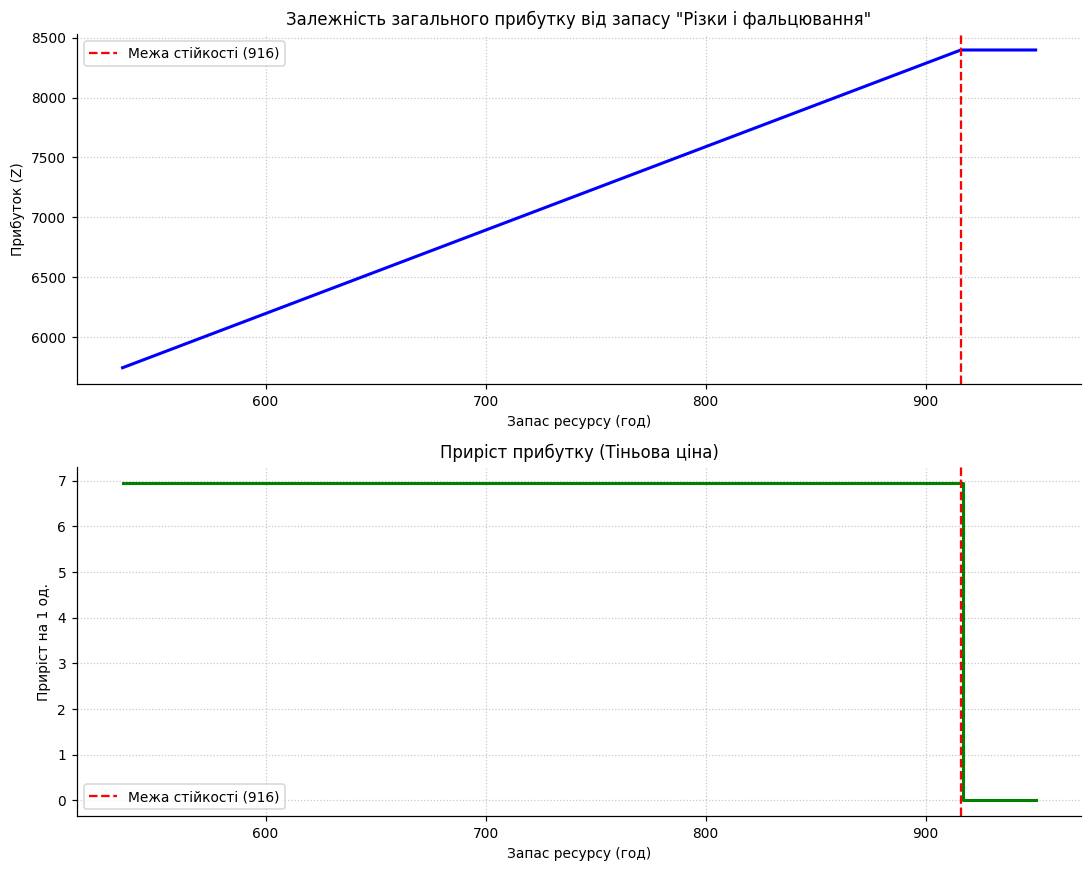

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

c = [-39, -55, -36, -26]
A_ub = [
    [5, 2, 0, 5],
    [1, 1, 3, 6],
    [6, 3, 5, 4],
    [2, 4, 6, 0],
    [4, 6, 2, 4]
]
base_b_ub = [788, 661, 458, 1005, 535]
bounds = [(0, None)] * 4

resource_range = range(535, 951)
profits = []

for b5 in resource_range:
    current_b_ub = base_b_ub.copy()
    current_b_ub[4] = b5  
    
    res = linprog(c, A_ub=A_ub, b_ub=current_b_ub, bounds=bounds, method='highs')
    if res.success:
        profits.append(-res.fun)
    else:
        profits.append(None)

increments = [profits[i] - profits[i-1] if i > 0 else 6.958333 for i in range(len(profits))]

limit_resource = None
base_increment = round(increments[1], 4)

for i in range(1, len(increments)):
   
    if round(increments[i], 4) != base_increment:
        limit_resource = resource_range[i-1] 
        break

print(f"Допустиме збільшення (Allowable Increase): {limit_resource - base_b_ub[4]} од.")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(resource_range, profits, color='blue', linewidth=2)
ax1.axvline(x=limit_resource, color='red', linestyle='--', label=f'Межа стійкості ({limit_resource})')
ax1.set_title('Залежність загального прибутку від запасу "Різки і фальцювання"')
ax1.set_ylabel('Прибуток (Z)')
ax1.set_xlabel('Запас ресурсу (год)')

ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

ax2.step(resource_range, increments, color='green', where='post', linewidth=2)
ax2.axvline(x=limit_resource, color='red', linestyle='--', label=f'Межа стійкості ({limit_resource})')
ax2.set_title('Приріст прибутку (Тіньова ціна)')
ax2.set_xlabel('Запас ресурсу (год)')
ax2.set_ylabel('Приріст на 1 од.')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)*: значення ресурсу можна збільшити на 381, бо при подальшому збільшенні прибуток зростати не буде. знайдена межа збігається з допустимим збільшенням.


---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [9]:
import numpy as np
from scipy.optimize import linprog

c = [-39, -55, -36, -26]
A_ub = [
    [5, 2, 0, 5],
    [1, 1, 3, 6],
    [6, 3, 5, 4],
    [2, 4, 6, 0],
    [4, 6, 2, 4] 
]
base_b_ub = [788, 661, 458, 1005, 535]
bounds = [(0, None)] * 4

resource_index = 4
offer_price = 5.0
offer_max_volume = 762

base_res = linprog(c, A_ub=A_ub, b_ub=base_b_ub, bounds=bounds, method='highs')
base_profit = -base_res.fun

test_b_ub = base_b_ub.copy()
test_b_ub[resource_index] += 1
test_res = linprog(c, A_ub=A_ub, b_ub=test_b_ub, bounds=bounds, method='highs')
shadow_price = -test_res.fun - base_profit

allowable_increase = 0
current_b_ub = base_b_ub.copy()
while True:
    allowable_increase += 1
    current_b_ub[resource_index] = base_b_ub[resource_index] + allowable_increase
    res = linprog(c, A_ub=A_ub, b_ub=current_b_ub, bounds=bounds, method='highs')
    
    current_shadow = (-res.fun - base_profit) / allowable_increase
    
    if abs(current_shadow - shadow_price) > 1e-5:
        allowable_increase -= 1
        break

print(f"Тіньова ціна ресурсу: {shadow_price:.6f}")
print(f"Ціна постачальника:   {offer_price:.6f}\n")

if offer_price < shadow_price:
    print("1. БРАТИ ЧИ НЕ БРАТИ?")
    print("Рішення: БРАТИ.")
    print("Причина: Ціна пропозиції (5.0) менша за тіньову ціну (~6.96). Це економічно вигідно.\n")
    
    purchase_volume = min(offer_max_volume, allowable_increase)
    print("2. СКІЛЬКИ БРАТИ?")
    print(f"Оптимальний обсяг: {purchase_volume} од.")
    print(f"Причина: Постачальник пропонує {offer_max_volume}, але межа стійкості становить {allowable_increase}.")
    print("Купувати більше немає сенсу, оскільки тіньова ціна впаде до нуля через дефіцит інших ресурсів.\n")
    
    expected_gain = purchase_volume * (shadow_price - offer_price)
    
    print("3. СКІЛЬКИ ЗАРОБИМО?")
    print(f"Розрахунковий чистий виграш: {expected_gain:.6f} од.")

base_b_ub[4] += purchase_volume

base_res = linprog(c, A_ub=A_ub, b_ub=base_b_ub, bounds=bounds, method='highs')

print(-base_res.fun-base_profit-(purchase_volume * offer_price))

Тіньова ціна ресурсу: 6.958333
Ціна постачальника:   5.000000

1. БРАТИ ЧИ НЕ БРАТИ?
Рішення: БРАТИ.
Причина: Ціна пропозиції (5.0) менша за тіньову ціну (~6.96). Це економічно вигідно.

2. СКІЛЬКИ БРАТИ?
Оптимальний обсяг: 381 од.
Причина: Постачальник пропонує 762, але межа стійкості становить 381.
Купувати більше немає сенсу, оскільки тіньова ціна впаде до нуля через дефіцит інших ресурсів.

3. СКІЛЬКИ ЗАРОБИМО?
Розрахунковий чистий виграш: 746.125000 од.
746.1249999999991


**Відповідь 6.1:**

* Брати чи ні і чому: брати. Ціна пропозиції (5.0) менша за тіньову ціну (~6.96). тобто з кожної додаткової одиниці ресурсу ми будемо получати 1.96 одиниць прибутку
* Скільки одиниць має сенс купити і чому не більше: 381 од. Постачальник пропонує 762, але межа стійкості становить 381, тому нема сенсу брати більше
* Очікуваний виграш: 746
* Перевірка прямим розв'язанням дала: 746.1249999999991


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [10]:
import numpy as np
from scipy.optimize import linprog

c = [-39, -55, -36, -26]
A_ub = [
    [5, 2, 0, 5],
    [1, 1, 3, 6],
    [6, 3, 5, 4],
    [2, 4, 6, 0],
    [4, 6, 2, 4]
]
b_ub = [788, 661, 458, 1005, 535]
bounds = [(0, None)] * 4

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')


ненульових = sum(1 for x in res.x if x > 1e-5)

звязних = sum(1 for slack in res.slack if abs(slack) < 1e-5)

print(f"Кількість виробів із ненульовим випуском: {ненульових}")
print(f"Кількість зв'язних обмежень: {звязних}")



Кількість виробів із ненульовим випуском: 2
Кількість зв'язних обмежень: 2


In [11]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** *(чи збіглися числа; що означала б розбіжність на практиці): так, числа збіглись. якщо би була розбіжність, то це означає, що в нас матриця A_ub вироджена. Скоріше всього проблема була би в тому, що певні рівняння обмежень означають одне й те саме, тобто ресурс закінчився один, але в результаті звязних обмежень у нас два*

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [12]:
import numpy as np
from scipy.optimize import linprog

c = [-39, -55, -36, -26]
A_ub = [
    [5, 2, 0, 5],
    [1, 1, 3, 6],
    [6, 3, 5, 4],
    [2, 4, 6, 0],
    [4, 6, 2, 4]
]
b_ub = [788, 661, 458, 1005, 535]
bounds = [(0, None)] * 4

res_cont = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
profit_cont = -res_cont.fun
x_cont = res_cont.x

print("1. НЕПЕРЕРВНИЙ РОЗВ'ЯЗОК:")
print(f"Випуск: Буклет={x_cont[0]:.2f}, Каталог={x_cont[1]:.2f}, Календар={x_cont[2]:.2f}, Плакат={x_cont[3]:.2f}")
print(f"Прибуток: {profit_cont:.2f}\n")

x_rounded = np.round(x_cont).astype(int)

resource_usage = np.dot(A_ub, x_rounded)
is_feasible = all(resource_usage <= b_ub)
profit_rounded = np.dot([-ci for ci in c], x_rounded)

print("2. ОКРУГЛЕНИЙ ПЛАН:")
print(f"Цілочисельний випуск: Буклет={x_rounded[0]}, Каталог={x_rounded[1]}, Календар={x_rounded[2]}, Плакат={x_rounded[3]}")
print(f"Чи допустимий план?: {'Так' if is_feasible else 'Ні (порушує обмеження ресурсів!)'}")
print(f"Прибуток округленого плану: {profit_rounded}\n")


res_int = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, integrality=1, method='highs')
profit_int = -res_int.fun
x_int = res_int.x

print("3. СПРАВЖНІЙ ЦІЛОЧИСЕЛЬНИЙ ОПТИМУМ:")
print(f"Випуск: Буклет={int(x_int[0])}, Каталог={int(x_int[1])}, Календар={int(x_int[2])}, Плакат={int(x_int[3] - 1e-5 if abs(x_int[3]-round(x_int[3]))<1e-3 else x_int[3])}") # форматування для чистоти виводу
print(f"Справжній цілочисельний прибуток: {profit_int:.2f}")

1. НЕПЕРЕРВНИЙ РОЗВ'ЯЗОК:
Випуск: Буклет=0.00, Каталог=73.29, Календар=47.62, Плакат=0.00
Прибуток: 5745.54

2. ОКРУГЛЕНИЙ ПЛАН:
Цілочисельний випуск: Буклет=0, Каталог=73, Календар=48, Плакат=0
Чи допустимий план?: Ні (порушує обмеження ресурсів!)
Прибуток округленого плану: 5743

3. СПРАВЖНІЙ ЦІЛОЧИСЕЛЬНИЙ ОПТИМУМ:
Випуск: Буклет=1, Каталог=73, Календар=46, Плакат=0
Справжній цілочисельний прибуток: 5710.00


**Відповідь 8.1:*
| Варіант |                             План |                                          Прибуток | Допустимий? |

| без умови цілочисельності |Буклет=0.00, Каталог=73.29, Календар=47.62, Плакат=0.00|    5745.54 |    По обмеженнях так, по факту ні   |
| округлений |               Буклет=0, Каталог=73, Календар=48, Плакат=0                | 5743   |      Ні, порушує обмеження|
| цілочисельний оптимум |    Буклет=1, Каталог=73, Календар=46, Плакат=0                | 5710   |      Так     |

**Висновок:** *(чи можна округлювати і чому): округлювати не можна. по-перше, при округленні та повторній перевірці обмежень можна вийти за межі. по-друге, розв'язок задачі лінійного програмування точний, і знаходить певні значення, при округленні яких ми можемо втрачати або не використовувати ресурси*


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [13]:
import numpy as np

постачальники = ['Стрий', 'Одеса', 'Суми']        
споживачі     = ['Бердичів', 'Олександрія', 'Гадяч', 'Дніпро']  


D = np.array([
    [436, 805, 890, 973],  
    [510, 392, 688, 453], 
    [516,  346, 133, 373]  
])

запас = [50, 60, 40]          
попит = [35, 45, 30, 40]      

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Бердичів,Олександрія,Гадяч,Дніпро
Стрий,436,805,890,973
Одеса,510,392,688,453
Суми,516,346,133,373


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [14]:


n_suppliers = len(постачальники)
n_consumers = len(споживачі)

c_linprog = D.flatten()

A_eq = np.zeros((n_suppliers + n_consumers, n_suppliers * n_consumers))

for i in range(n_suppliers):
    for j in range(n_consumers):
        A_eq[i, i * n_consumers + j] = 1

for j in range(n_consumers):
    for i in range(n_suppliers):
        A_eq[n_suppliers + j, i * n_consumers + j] = 1

b_eq = np.array(запас + попит)
bounds = [(0, None)] * (n_suppliers * n_consumers)

res_linprog = linprog(c_linprog, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print("\n==========================================")
print("     РЕЗУЛЬТАТ scipy.optimize.linprog     ")
print("==========================================")
print(f"Статус розв'язку: {res_linprog.message}")
print(f"Сумарні транспортні витрати (км): {res_linprog.fun:.2f}\n")

print("Оптимальний план перевезень:")
plan_linprog = res_linprog.x.reshape((n_suppliers, n_consumers))
for i in range(n_suppliers):
    for j in range(n_consumers):
        if plan_linprog[i, j] > 1e-5:
            print(f"  {постачальники[i]} -> {споживачі[j]}: {plan_linprog[i, j]:.0f} од.")

print("\nТіньові ціни (двоїсті змінні marg_b):")
marginals = res_linprog.eqlin.marginals

print("  Постачальники:")
for i in range(n_suppliers):
    print(f"    {постачальники[i]}: {marginals[i]:.2f}")

print("  Споживачі:")
for j in range(n_consumers):
    print(f"    {споживачі[j]}: {marginals[n_suppliers + j]:.2f}")


     РЕЗУЛЬТАТ scipy.optimize.linprog     
Статус розв'язку: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Сумарні транспортні витрати (км): 60405.00

Оптимальний план перевезень:
  Стрий -> Бердичів: 35 од.
  Стрий -> Олександрія: 15 од.
  Одеса -> Олександрія: 30 од.
  Одеса -> Дніпро: 30 од.
  Суми -> Гадяч: 30 од.
  Суми -> Дніпро: 10 од.

Тіньові ціни (двоїсті змінні marg_b):
  Постачальники:
    Стрий: -0.00
    Одеса: -413.00
    Суми: -493.00
  Споживачі:
    Бердичів: 436.00
    Олександрія: 805.00
    Гадяч: 626.00
    Дніпро: 866.00


In [15]:
C = [
    [436, 805, 890, 973],
    [510, 392, 688, 453],
    [516, 346, 133, 373]
]

supply_vals = {'Стрий': 50, 'Одеса': 60, 'Суми': 40}
demand_vals = {'Бердичів': 35, 'Олександрія': 45, 'Гадяч': 30, 'Дніпро': 40}

costs = pulp.makeDict([постачальники, споживачі], C)

prob = pulp.LpProblem("Transportation_Problem", pulp.LpMinimize)

x = pulp.LpVariable.dicts("Route", (постачальники, споживачі), lowBound=0, cat='Continuous')

prob += pulp.lpSum([x[s][c] * costs[s][c] for s in постачальники for c in споживачі]), "Total_Cost"

supply_constraints = {}
for s in постачальники:
    supply_constraints[s] = pulp.lpSum([x[s][c] for c in споживачі]) == supply_vals[s]
    prob += supply_constraints[s], f"Supply_{s}"

demand_constraints = {}
for c in споживачі:
    demand_constraints[c] = pulp.lpSum([x[s][c] for s in постачальники]) == demand_vals[c]
    prob += demand_constraints[c], f"Demand_{c}"

prob.solve(pulp.PULP_CBC_CMD(msg=False))

if pulp.LpStatus[prob.status] == "Optimal":
    print("--- Оптимальний план перевезень ---")
    for s in постачальники:
        for c in споживачі:
            if x[s][c].varValue > 0.01:
                print(f"{s} -> {c}: {round(x[s][c].varValue)} од. (тариф: {costs[s][c]})")

    print(f"\nСумарна вартість перевезень: {round(pulp.value(prob.objective))}")

    print("\n--- Тіньові ціни обмежень (Shadow Prices / Dual Values) ---")
    print("Постачальники (Запаси):")
    for s in постачальники:
        print(f"  {s}: {round(supply_constraints[s].pi, 2)}")

    print("Споживачі (Попит):")
    for c in споживачі:
        print(f"  {c}: {round(demand_constraints[c].pi, 2)}")
else:
    print("Задачу не вдалося розв'язати. Статус:", pulp.LpStatus[prob.status])

--- Оптимальний план перевезень ---
Стрий -> Бердичів: 35 од. (тариф: 436)
Стрий -> Олександрія: 15 од. (тариф: 805)
Одеса -> Олександрія: 30 од. (тариф: 392)
Одеса -> Дніпро: 30 од. (тариф: 453)
Суми -> Гадяч: 30 од. (тариф: 133)
Суми -> Дніпро: 10 од. (тариф: 373)

Сумарна вартість перевезень: 60405

--- Тіньові ціни обмежень (Shadow Prices / Dual Values) ---
Постачальники (Запаси):
  Стрий: 626.0
  Одеса: 213.0
  Суми: 133.0
Споживачі (Попит):
  Бердичів: -190.0
  Олександрія: 179.0
  Гадяч: 0.0
  Дніпро: 240.0


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [16]:
print("Різниця для постачальників (Δ):")
for i, s in enumerate(постачальники):
    scipy_shadow = marginals[i]
    pulp_shadow = supply_constraints[s].pi
    diff = pulp_shadow - scipy_shadow 
    print(f"  {s}: {diff:.2f}")

print("\nРізниця для споживачів (Δ):")
for j, c in enumerate(споживачі):
    scipy_shadow = marginals[n_suppliers + j]
    pulp_shadow = demand_constraints[c].pi
    diff = pulp_shadow - scipy_shadow 
    print(f"  {c}: {diff:.2f}")

Різниця для постачальників (Δ):
  Стрий: 626.00
  Одеса: 626.00
  Суми: 626.00

Різниця для споживачів (Δ):
  Бердичів: -626.00
  Олександрія: -626.00
  Гадяч: -626.00
  Дніпро: -626.00


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: 60405
* Тіньові ціни збіглися чи ні: ні
* Яку закономірність ви побачили в різниці: різниця для постачальників = 626, різниця для споживачів = -626
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: загальна вартість перевезень та оптимальний план для обох варіантів однаковий, проте тіньові ціни відрізняються, оскільки різні методи беруть різне константне значення(оскільки в нас 6 унікальних рівнянь та 7 змінних, то для одної змінної метод сам бере значення. В нашому випадку це значення відрізняється на 626) якщо розраховувати нове перевезення 1 одиниці товару з одного міста в склад, то значення приросту бюджету для обох методів буде однакове, бо 626 в результаті скоротиться.


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [17]:

non_zero_shipments = sum(
    1 for s in постачальники for c in споживачі if x[s][c].varValue > 0.01
)


binding_constraints = 0

for s in постачальники:
    if abs(supply_constraints[s].slack) < 1e-5:
        binding_constraints += 1

for c in споживачі:
    if abs(demand_constraints[c].slack) < 1e-5:
        binding_constraints += 1

print("\n--- Аналіз моделі ---")
print(f"Кількість ненульових перевезень: {non_zero_shipments}")
print(f"Кількість зв'язних обмежень: {binding_constraints}")


--- Аналіз моделі ---
Кількість ненульових перевезень: 6
Кількість зв'язних обмежень: 7


**Відповідь 11.1:**

* Ненульових перевезень:6
* Зв'язних обмежень:7
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: Ця задача є збалансованою — кількість запасів = кількості попиту. За таких умов весь товар вивозиться зі складів та всі склади заповнюються, немає надлишку чи нестачі, тому всі рівняння обмежень виконуються
* На скільки ненульових перевезень менше і чому саме на стільки: менше на 1 ніж зв'язних обмежень . математично це працює так: скільки є унікальних умов, рівно стільки ненульових перевезень треба для того, щоб задовольнити умову. а виконується це тому, що: якщо у нас є 3 suppliers і 4 consumers, то коли ми вивезли товар для 2 suppliers та привезли для 3 consumers, то залишок у 3 supplier буде рівний потребі у 4 consumer, що можна просто вирахувати за методом виключення.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plan_matrix = np.array([
    [x[s][c].varValue if x[s][c].varValue is not None else 0 for c in споживачі]
    for s in постачальники
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(C, 
            annot=True,          
            fmt="d",          
            cmap="YlOrRd",     
            xticklabels=споживачі, 
            yticklabels=постачальники, 
            cbar_kws={'label': 'Вартість (у.о.)'},
            ax=axes[0])

axes[0].set_title("Матриця тарифів (відстаней)", fontsize=14, pad=15)
axes[0].set_xlabel("Споживачі", fontsize=12)
axes[0].set_ylabel("Постачальники", fontsize=12)

axes[0].tick_params(axis='x', rotation=45) 
axes[0].tick_params(axis='y', rotation=0)


sns.heatmap(plan_matrix, 
            annot=True,         
            fmt=".0f",      
            cmap="Greens",    
            xticklabels=споживачі, 
            yticklabels=постачальники, 
            cbar_kws={'label': 'Обсяг перевезень (од.)'},
            ax=axes[1])

axes[1].set_title("Оптимальний план перевезень", fontsize=14, pad=15)
axes[1].set_xlabel("Споживачі", fontsize=12)
axes[1].set_ylabel("Постачальники", fontsize=12)

axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()

plt.show()

**Висновок:** *(ліва теплова карта відображає вартість перевезення(кількість км), права - оптимальний план. можемо побачити, що в оптимальному плані в більшості оминаються найдорожчі перевезення.)*

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [ ]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = (
    "Код для візуалізації теплових карт (Seaborn) та підрахунку зв'язних обмежень перевірено "
    "на працездатність та відповідність змін потенціалів (U+V=C), константи зсуву 626 між SciPy та PuLP, а також властивості slack "
)

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

---
# Крок 13. Фінальна самоперевірка

In [ ]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток1 - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')